# imports

In [1]:
import os
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
from scipy import stats

In [2]:
import lifesim
import os, sys
os.chdir("/home/kirschkobold/documents/life_internship/LIFEsim_yields")
sys.path.insert(0, os.getcwd())

# check files: EEC25 and BrysonDressingBaselineMinus

default1 = bryson dressing baseline minus

default2 = sag dressing baseline

In [4]:
df_default = pd.read_hdf("/home/kirschkobold/documents/life_internship/LIFEsim_yields/eta_catalogs/ap_merged_default2/diameter_3/sweep_diameter_3_catalog.hdf5", sep="\t", header=1)
df_etas = pd.read_hdf("/home/kirschkobold/documents/life_internship/LIFEsim_yields/eta_catalogs/ap_merged_EEC25/diameter_3/sweep_diameter_3_catalog.hdf5", sep="\t", header=1)

In [5]:
df_etas.columns

Index(['radius_p', 'p_orb', 'mass_p', 'ecc_p', 'inc_p', 'large_omega_p',
       'small_omega_p', 'theta_p', 'albedo_bond', 'albedo_geom_vis',
       'albedo_geom_mir', 'z', 'semimajor_p', 'sep_p', 'angsep', 'maxangsep',
       'flux_p', 'fp', 'temp_p', 'radius_s', 'mass_s', 'temp_s', 'distance_s',
       'ra', 'dec', 'nuniverse', 'nstar', 'stype', 'id', 'name_s', 'lon',
       'lat', 's_in', 's_out', 'l_sun', 'hz_in', 'hz_out', 'hz_center',
       'habitable', 'snr_1h', 'baseline', 'maxsep_snr_1h'],
      dtype='str')

In [6]:
columns = df_etas.columns
numeric_cols = df_etas.select_dtypes(include=[np.number]).columns
categorical_cols = [c for c in columns if c not in numeric_cols]

In [7]:
results = []
for col in numeric_cols:
    a = df_default[col].dropna().values
    b = df_etas[col].dropna().values
    if len(a) == 0 or len(b) == 0:
        continue
    ks_stat, ks_p = stats.ks_2samp(a, b)
    results.append({
        "column": col,
        "mean_default": np.mean(a),
        "mean_etas": np.mean(b),
        "std_default": np.std(a),
        "std_etas": np.std(b),
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
    })

summary_df = pd.DataFrame(results).sort_values("ks_stat", ascending=False)
summary_df

,column,mean_default,mean_etas,std_default,std_etas,ks_stat,ks_pvalue
27,id,8.395742e+06,457968.000000,5.534591e+06,264408.236755,0.959988,0.000000
25,nuniverse,4.949607e+01,249.385494,2.885610e+01,144.271776,0.799645,0.000000
26,nstar,3.132961e+03,659.758824,1.966788e+03,483.370620,0.715588,0.000000
16,flux_p,8.968312e+01,0.769003,5.995521e+03,0.533367,0.555352,0.000000
22,distance_s,3.224578e+01,22.443019,1.128012e+01,5.969713,0.553664,0.000000
18,temp_p,2.344805e+02,216.124888,2.859303e+02,44.203939,0.483183,0.000000
37,baseline,7.368075e+01,38.265381,2.834106e+01,26.443326,0.453275,0.000000
0,radius_p,2.403307e+00,1.196571,2.421286e+00,0.555942,0.293786,0.000000
15,maxangsep,1.191946e-01,0.122931,1.703079e-01,0.246274,0.284979,0.000000
20,mass_s,7.714464e-01,1.103932,3.185377e-01,0.450146,0.276236,0.000000


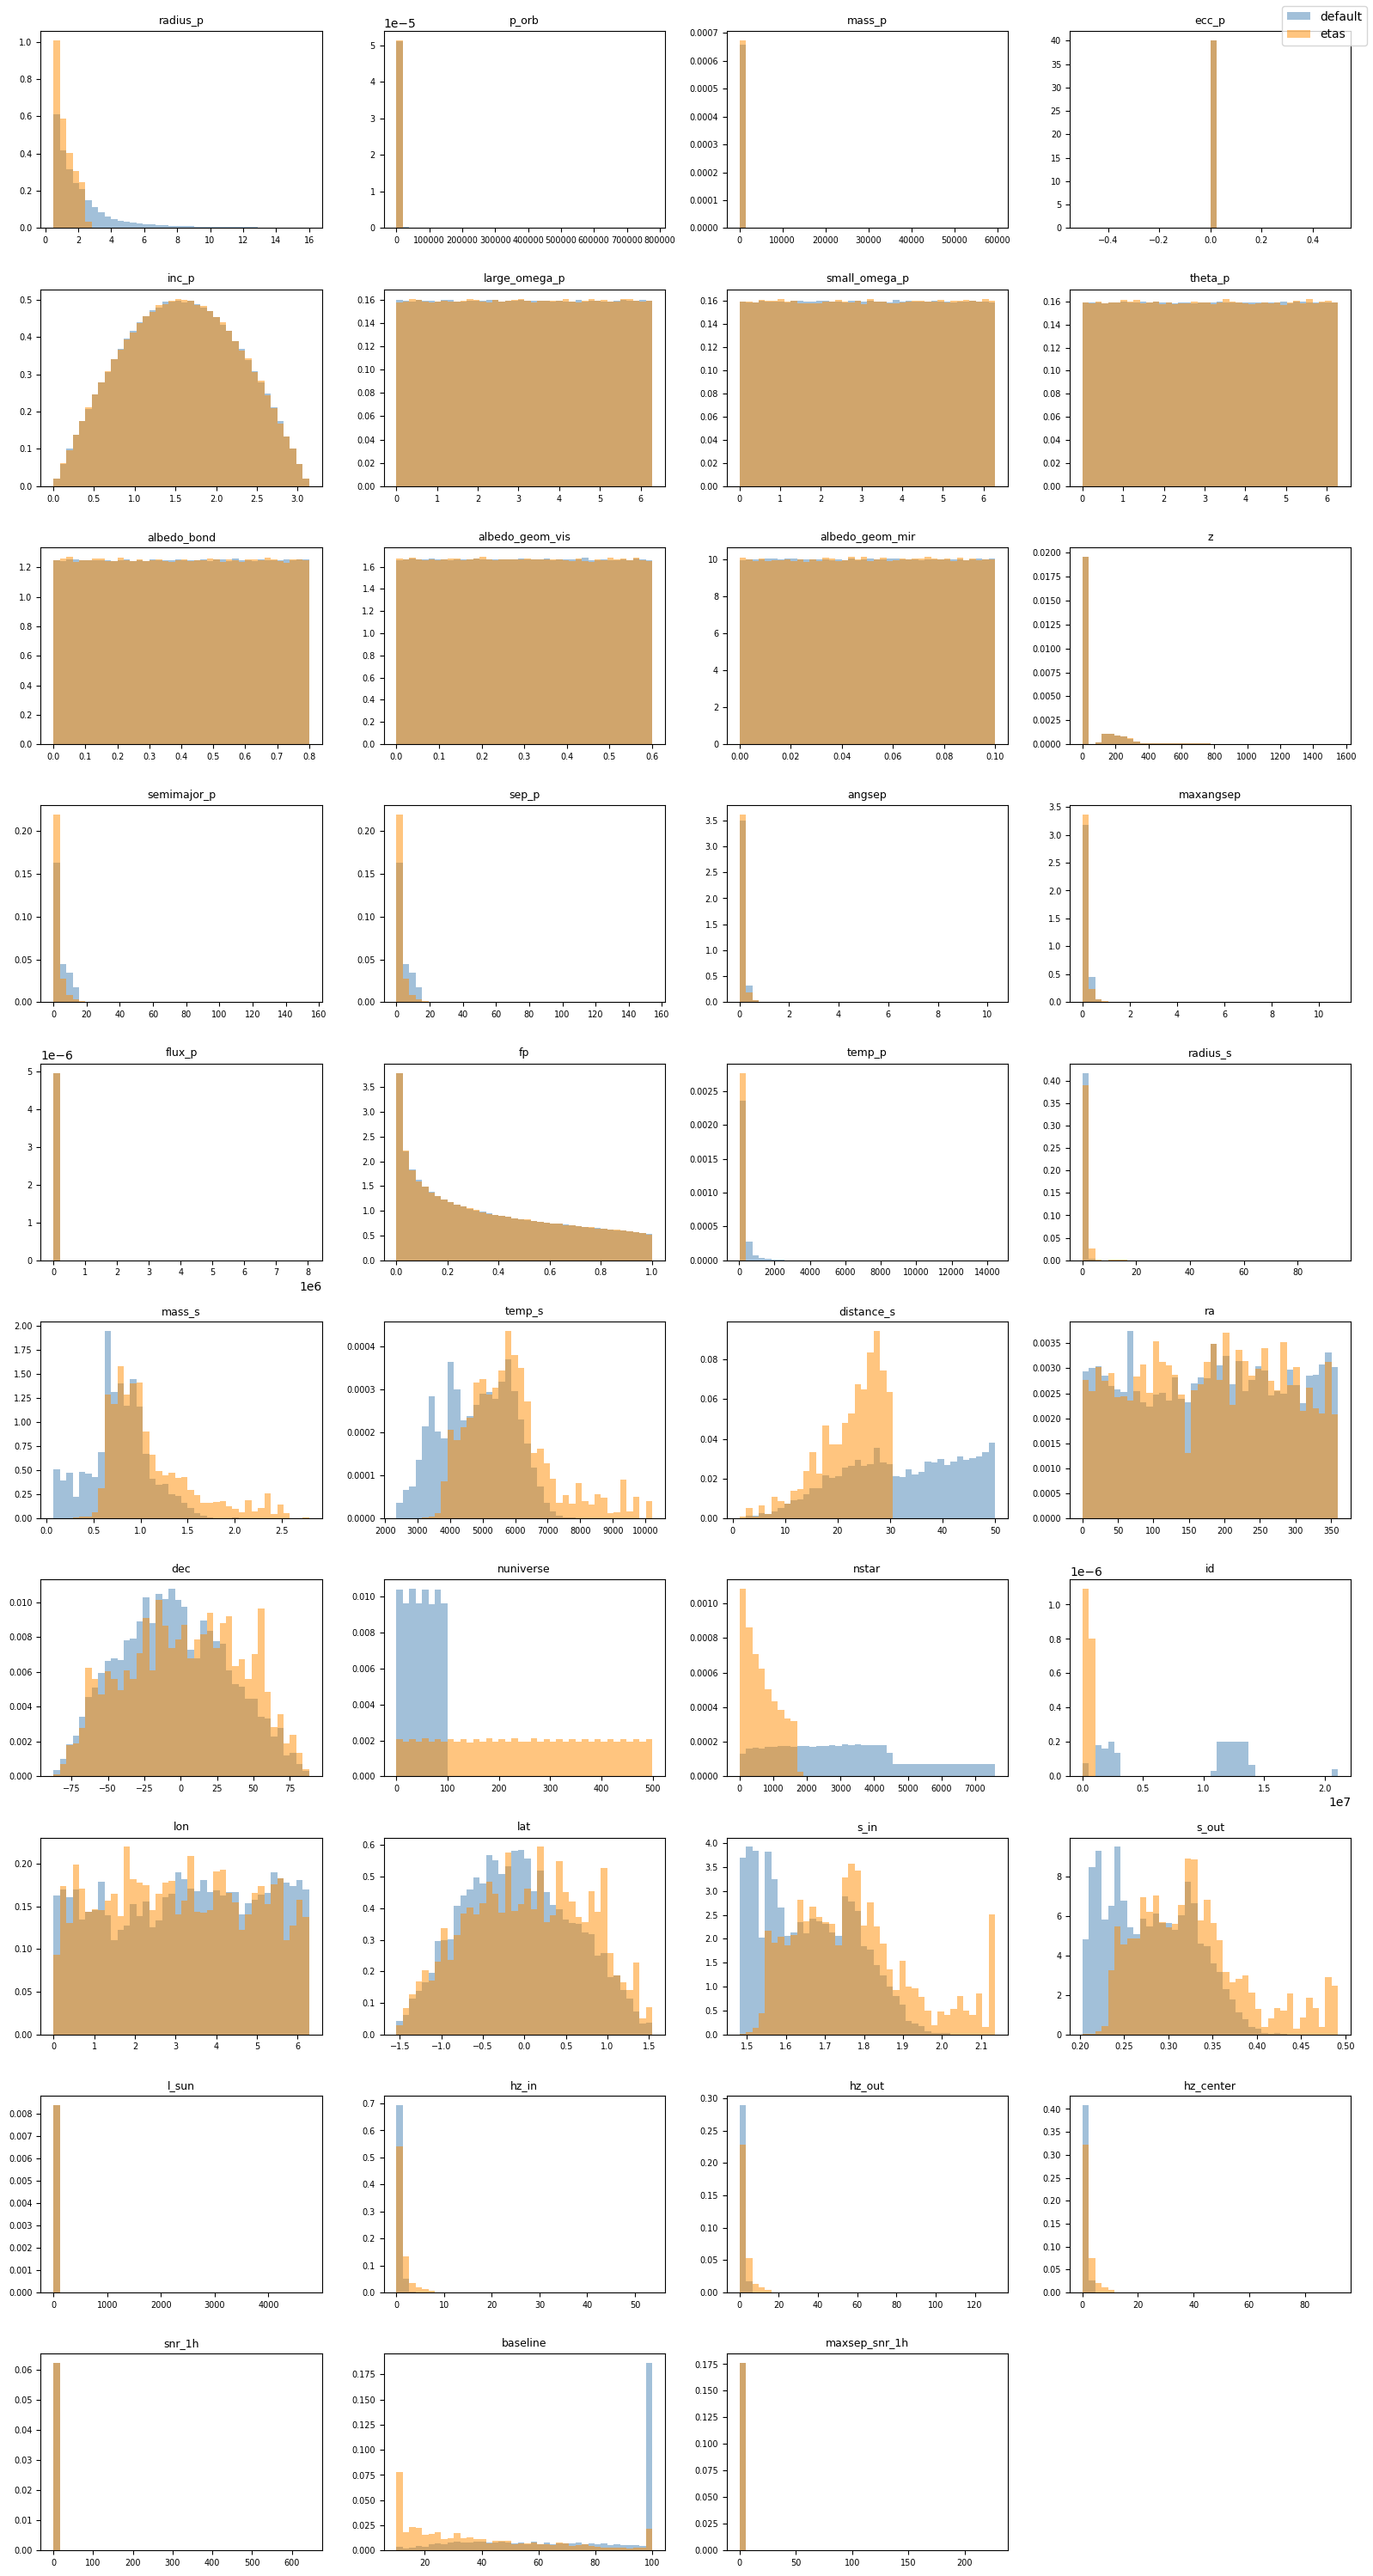

In [8]:
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    a = df_default[col].dropna()
    b = df_etas[col].dropna()
    bins = np.histogram_bin_edges(pd.concat([a, b]), bins=40)
    ax.hist(a, bins=bins, alpha=0.5, label="default", density=True, color="steelblue")
    ax.hist(b, bins=bins, alpha=0.5, label="etas", density=True, color="darkorange")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

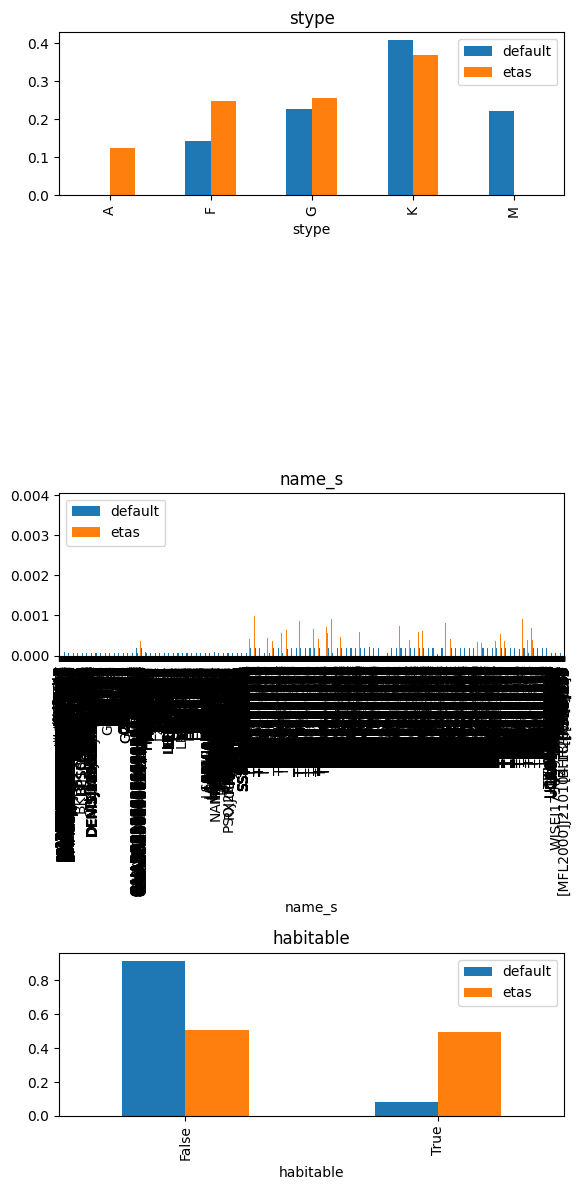

In [9]:
if categorical_cols:
    fig2, axes2 = plt.subplots(len(categorical_cols), 1, figsize=(6, 4 * len(categorical_cols)))
    if len(categorical_cols) == 1:
        axes2 = [axes2]
    for ax, col in zip(axes2, categorical_cols):
        counts_default = df_default[col].value_counts(normalize=True)
        counts_etas = df_etas[col].value_counts(normalize=True)
        combined = pd.DataFrame({"default": counts_default, "etas": counts_etas}).fillna(0)
        combined.plot(kind="bar", ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

## experiments

In [10]:
experiments = {
    "Experiment_1": dict(in_HZ=True, radius_p_min=0.5, radius_p_max=1.5,
                          sample_size=50, temp_s_min=4370.0, temp_s_max=7310.0),
    "Experiment_2": dict(in_HZ=True, radius_p_min=0.5, radius_p_max=1.5,
                          sample_size=25, temp_s_min=3320.0, temp_s_max=4369.0),
}

def filter_experiment(df, cfg):
    mask = (
        (df["radius_p"] >= cfg["radius_p_min"]) &
        (df["radius_p"] <= cfg["radius_p_max"]) &
        (df["temp_s"] >= cfg["temp_s_min"]) &
        (df["temp_s"] <= cfg["temp_s_max"])
    )
    if cfg["in_HZ"]:
        mask &= df["habitable"].astype(bool)
    return df[mask].copy()

In [11]:
subsets = {}
for exp_name, cfg in experiments.items():
    subsets[(exp_name, "default")] = filter_experiment(df_default, cfg)
    subsets[(exp_name, "etas")] = filter_experiment(df_etas, cfg)

for key, sub in subsets.items():
    print(key, "->", len(sub), "rows")

('Experiment_1', 'default') -> 191996 rows
('Experiment_1', 'etas') -> 352884 rows
('Experiment_2', 'default') -> 133435 rows
('Experiment_2', 'etas') -> 55051 rows


In [12]:
def compare_two_groups(df_a, df_b, numeric_cols, label_a, label_b):
    results = []
    for col in numeric_cols:
        a = df_a[col].dropna().values
        b = df_b[col].dropna().values
        if len(a) == 0 or len(b) == 0:
            continue
        ks_stat, ks_p = stats.ks_2samp(a, b)
        results.append({
            "column": col,
            f"mean_{label_a}": np.mean(a), f"mean_{label_b}": np.mean(b),
            f"std_{label_a}": np.std(a), f"std_{label_b}": np.std(b),
            "ks_stat": ks_stat, "ks_pvalue": ks_p,
        })
    return pd.DataFrame(results).sort_values("ks_stat", ascending=False)

exp1_compare = compare_two_groups(
    subsets[("Experiment_1", "default")],
    subsets[("Experiment_1", "etas")],
    numeric_cols, "default", "etas",
)

exp2_compare = compare_two_groups(
    subsets[("Experiment_2", "default")],
    subsets[("Experiment_2", "etas")],
    numeric_cols, "default", "etas",
)

exp1_compare

,column,mean_default,mean_etas,std_default,std_etas,ks_stat,ks_pvalue
27,id,9.599327e+06,458098.148771,4.887494e+06,264376.316311,0.972994,0.000000e+00
25,nuniverse,4.951094e+01,249.442981,2.880801e+01,144.254768,0.799753,0.000000e+00
22,distance_s,3.600079e+01,22.401432,1.012714e+01,5.890844,0.724916,0.000000e+00
26,nstar,1.901933e+03,654.200086,1.233264e+03,408.092536,0.552787,0.000000e+00
37,baseline,5.739427e+01,36.887198,2.676022e+01,21.450576,0.306543,0.000000e+00
15,maxangsep,4.122658e-02,0.078403,3.411846e-02,0.139526,0.287176,0.000000e+00
14,angsep,3.236492e-02,0.061559,2.932927e-02,0.116207,0.264240,0.000000e+00
38,maxsep_snr_1h,8.260220e-02,0.130332,1.971452e-01,0.332512,0.173016,0.000000e+00
24,dec,-9.477450e+00,1.937831,3.655078e+01,40.244341,0.161966,0.000000e+00
29,lat,-1.530124e-01,0.029623,6.439183e-01,0.722536,0.141783,0.000000e+00


In [13]:
exp2_compare

,column,mean_default,mean_etas,std_default,std_etas,ks_stat,ks_pvalue
26,nstar,4.965189e+03,1398.414797,1.184939e+03,327.441308,0.994964,0.000000e+00
27,id,5.722905e+06,459609.267679,5.924208e+06,265141.974745,0.929516,0.000000e+00
25,nuniverse,4.944955e+01,249.903272,2.885510e+01,144.672977,0.798187,0.000000e+00
21,temp_s,3.718627e+03,4082.788579,2.969955e+02,184.616361,0.595185,0.000000e+00
30,s_in,1.536067e+00,1.566058,2.416109e-02,0.016835,0.595185,0.000000e+00
31,s_out,2.307539e-01,0.243435,1.023522e-02,0.006994,0.595185,0.000000e+00
32,l_sun,7.655811e-02,1.774059,5.594563e-01,23.437331,0.570007,0.000000e+00
33,hz_in,1.828639e-01,0.340861,1.258033e-01,1.009924,0.569299,0.000000e+00
35,hz_center,3.261430e-01,0.602531,2.218867e-01,1.789640,0.566908,0.000000e+00
34,hz_out,4.694221e-01,0.864200,3.179837e-01,2.569389,0.566605,0.000000e+00


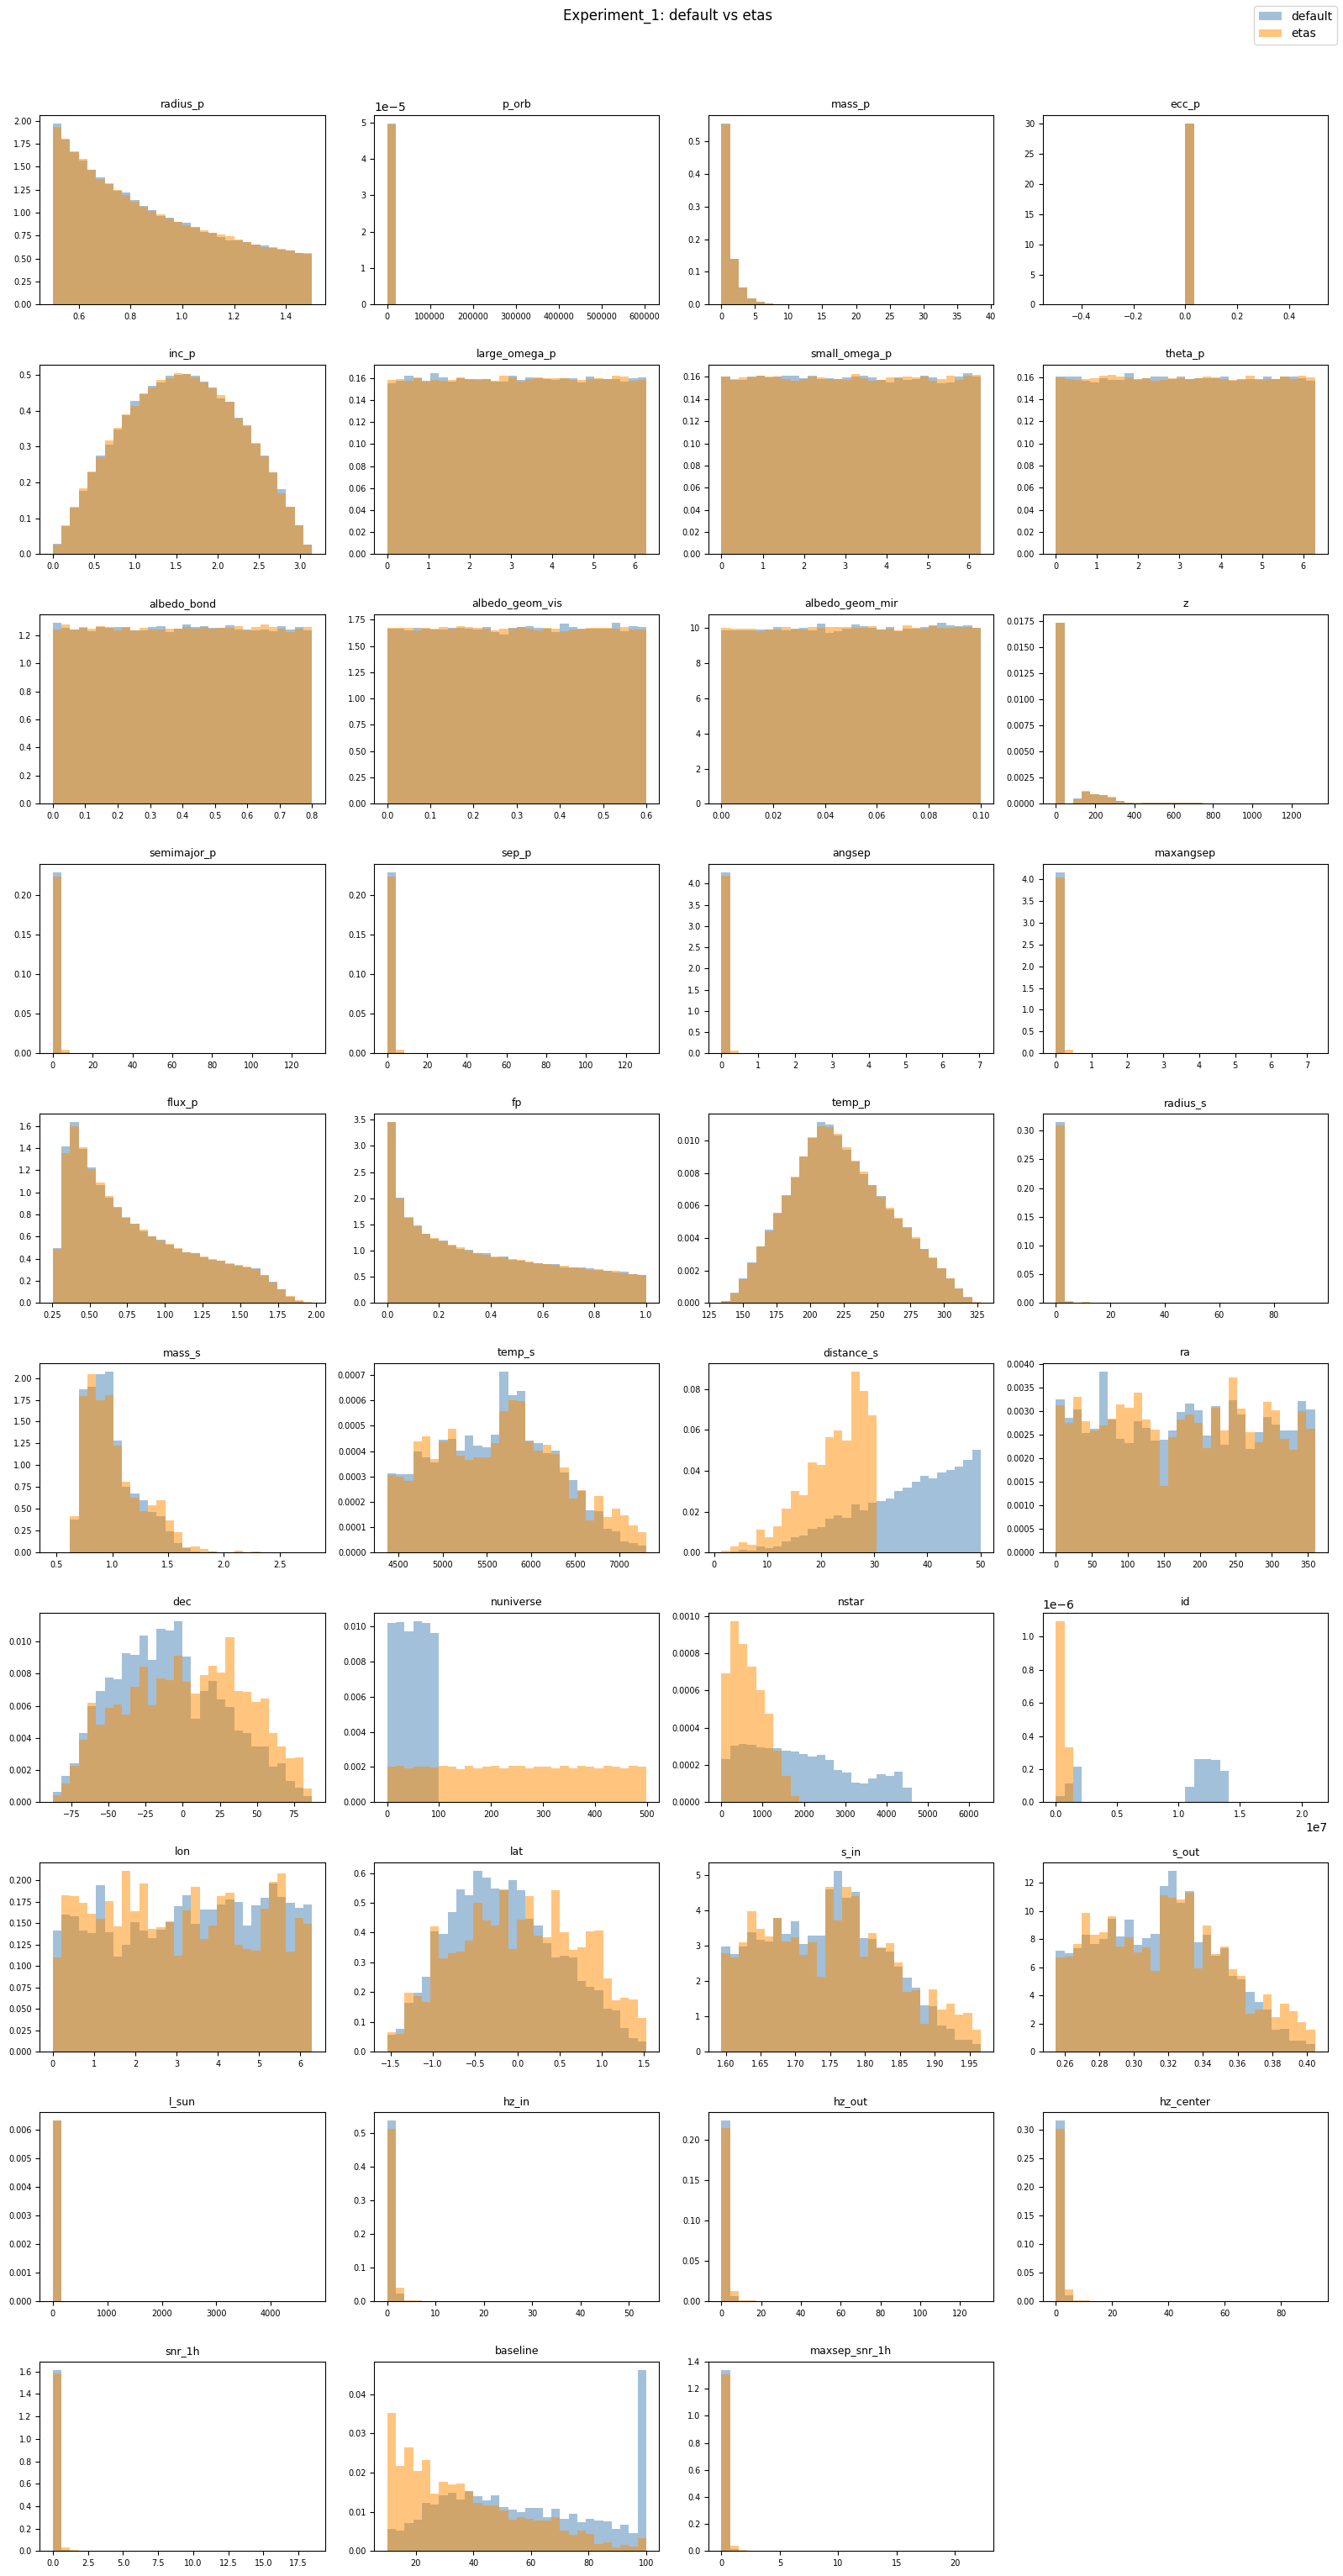

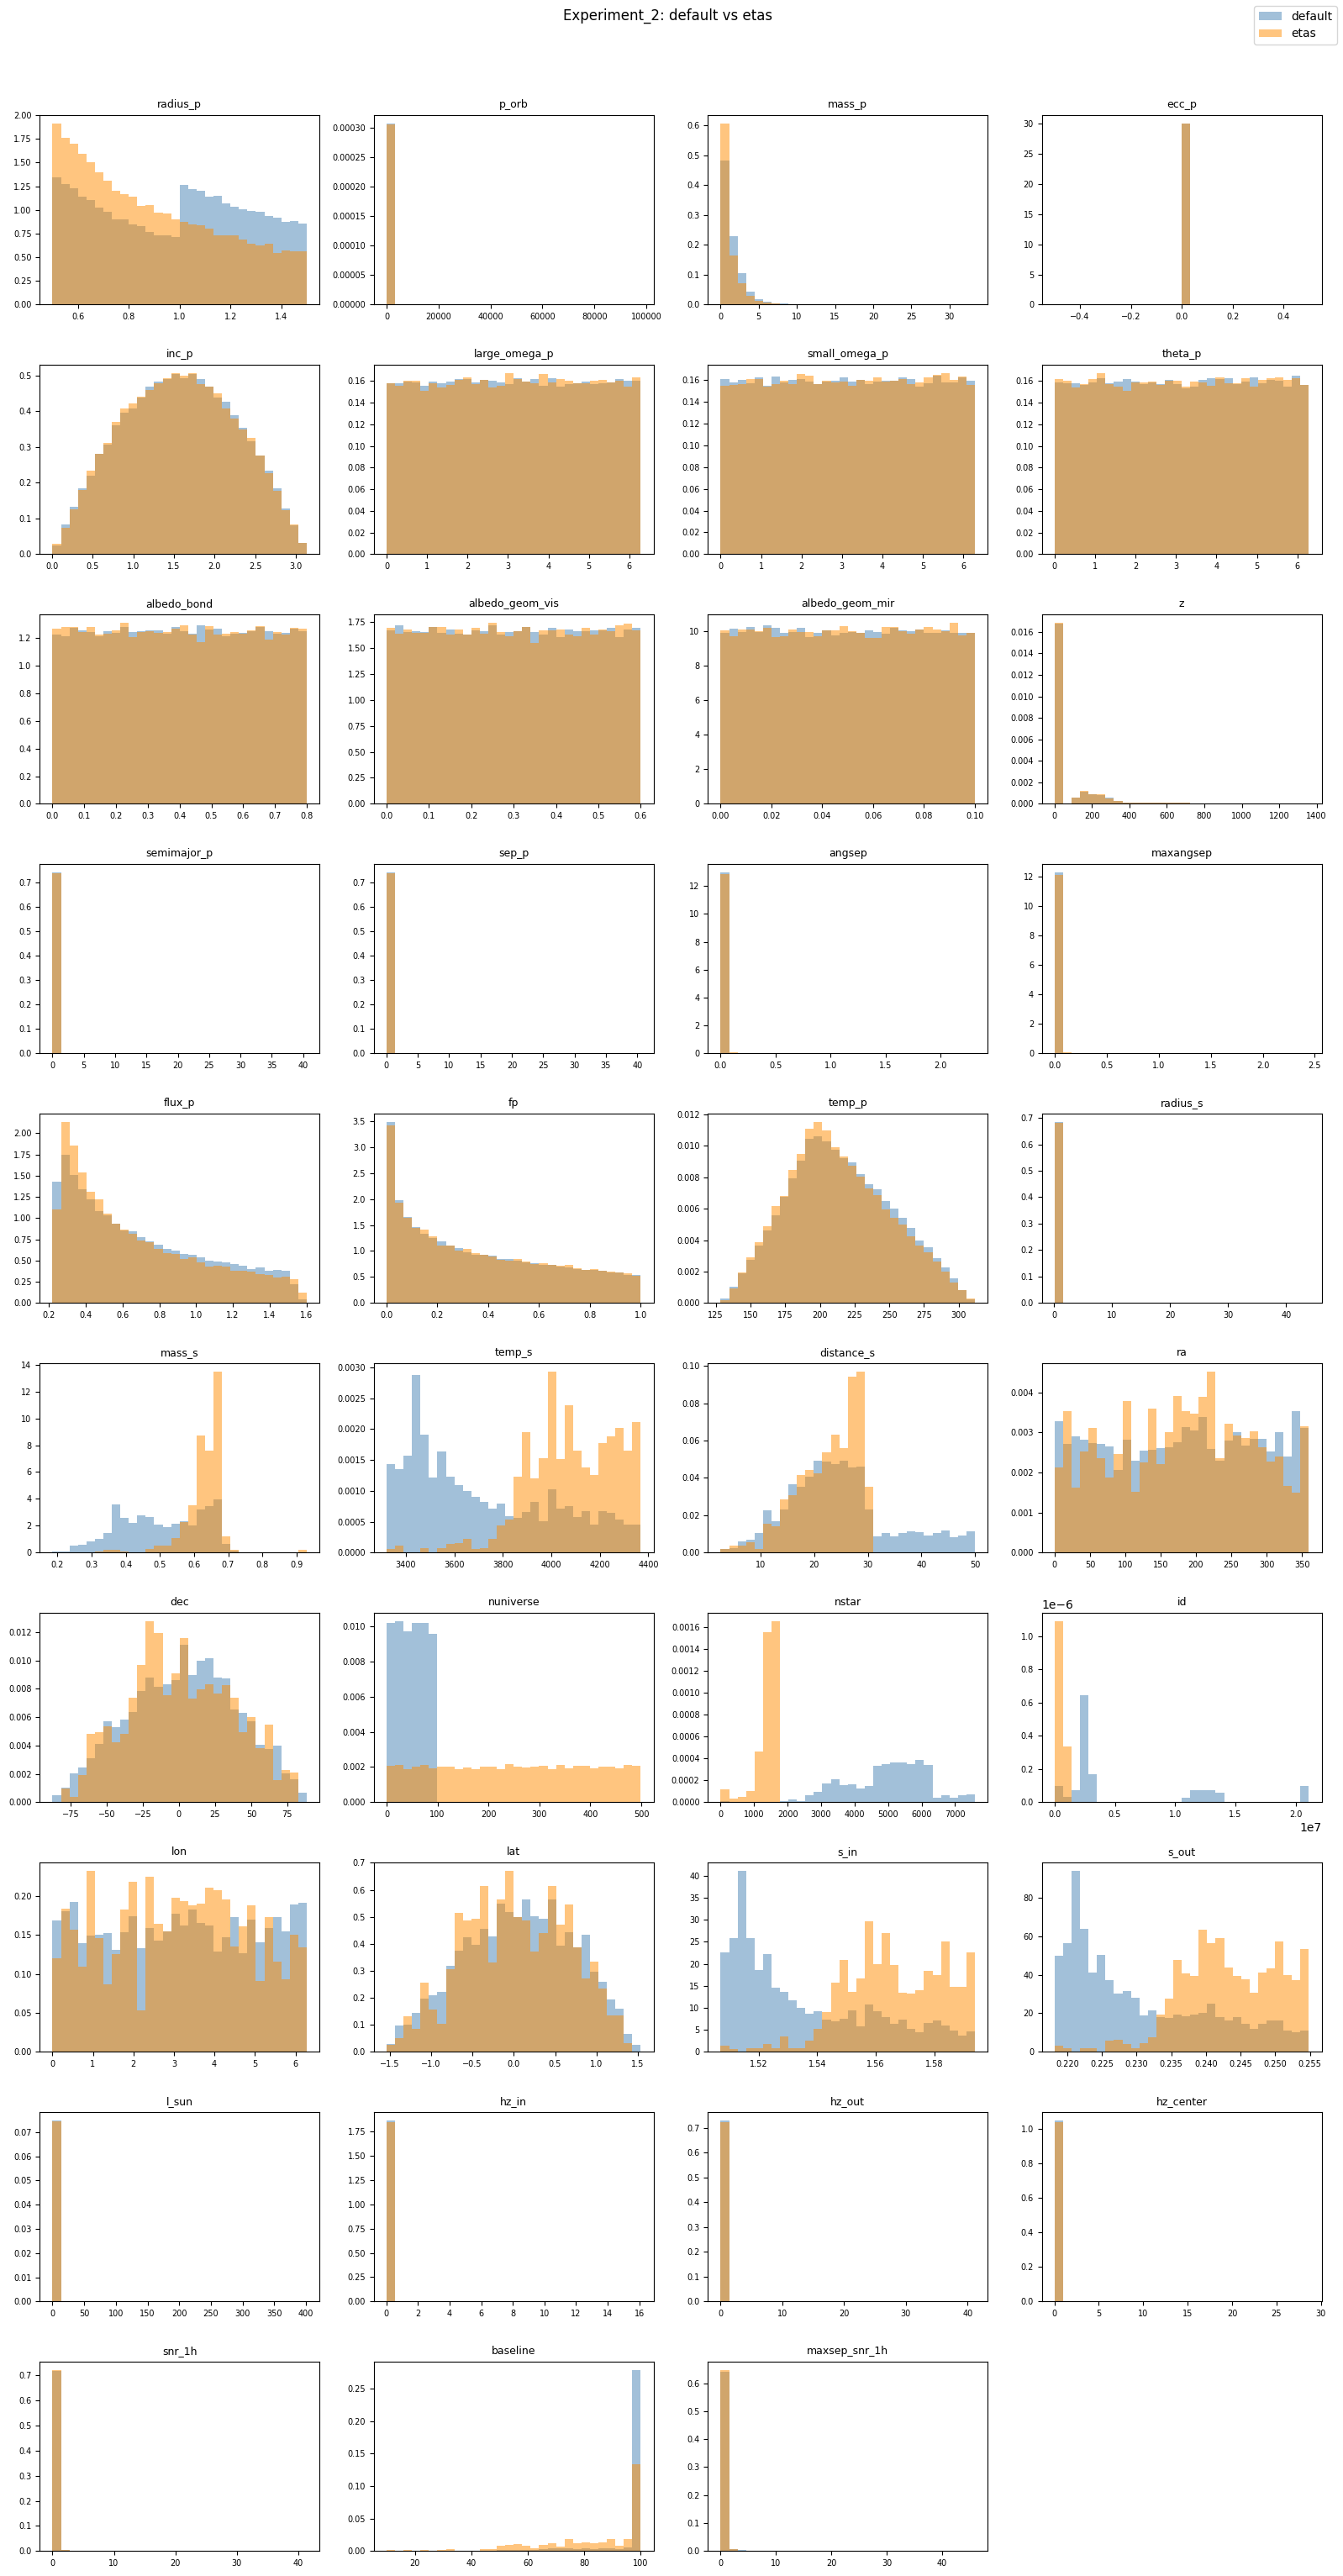

In [14]:
def plot_experiment_comparison(df_a, df_b, label_a, label_b, numeric_cols, title):
    n_cols = 4
    n_rows = int(np.ceil(len(numeric_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        a = df_a[col].dropna()
        b = df_b[col].dropna()
        if len(a) == 0 and len(b) == 0:
            continue
        bins = np.histogram_bin_edges(pd.concat([a, b]), bins=30)
        ax.hist(a, bins=bins, alpha=0.5, label=label_a, density=True, color="steelblue")
        ax.hist(b, bins=bins, alpha=0.5, label=label_b, density=True, color="darkorange")
        ax.set_title(col, fontsize=9)
        ax.tick_params(labelsize=7)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

plot_experiment_comparison(
    subsets[("Experiment_1", "default")], subsets[("Experiment_1", "etas")],
    "default", "etas", numeric_cols,
    "Experiment_1: default vs etas",
)

plot_experiment_comparison(
    subsets[("Experiment_2", "default")], subsets[("Experiment_2", "etas")],
    "default", "etas", numeric_cols,
    "Experiment_2: default vs etas",
)

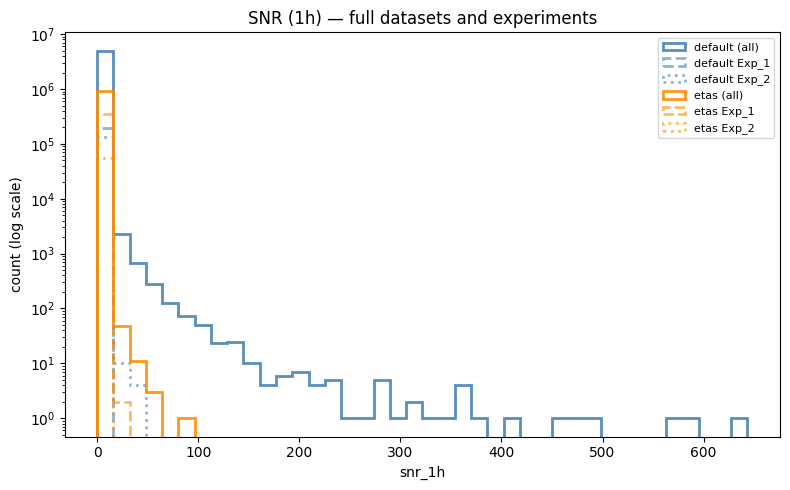

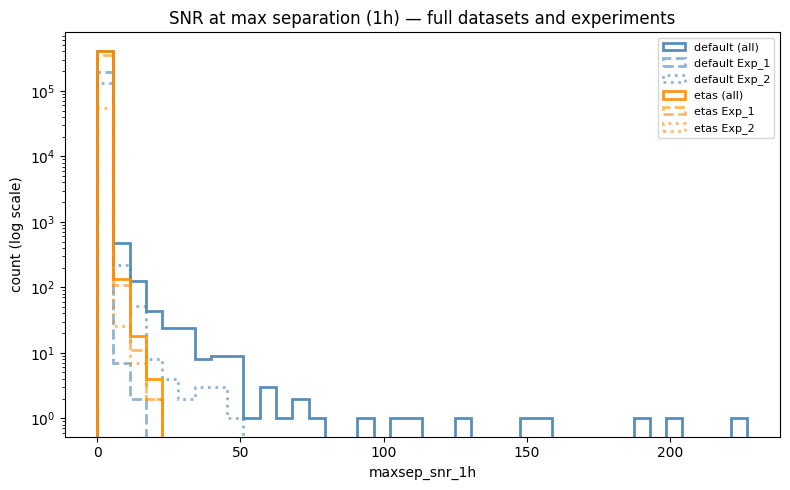

In [15]:
def plot_snr_overview(col, title):
    fig, ax = plt.subplots(figsize=(8, 5))

    groups = [
        ("default (all)", df_default[col].dropna(), "steelblue", "-", 0.9),
        ("default Exp_1", subsets[("Experiment_1", "default")][col].dropna(), "steelblue", "--", 0.6),
        ("default Exp_2", subsets[("Experiment_2", "default")][col].dropna(), "steelblue", ":", 0.6),
        ("etas (all)", df_etas[col].dropna(), "darkorange", "-", 0.9),
        ("etas Exp_1", subsets[("Experiment_1", "etas")][col].dropna(), "darkorange", "--", 0.6),
        ("etas Exp_2", subsets[("Experiment_2", "etas")][col].dropna(), "darkorange", ":", 0.6),
    ]

    all_vals = pd.concat([g[1] for g in groups])
    bins = np.histogram_bin_edges(all_vals, bins=40)

    for label, data, color, linestyle, alpha in groups:
        if len(data) == 0:
            continue
        ax.hist(data, bins=bins, histtype="step", linewidth=2,
                linestyle=linestyle, color=color, alpha=alpha, label=label)

    ax.set_yscale("log")
    ax.set_xlabel(col)
    ax.set_ylabel("count (log scale)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_snr_overview("snr_1h", "SNR (1h) — full datasets and experiments")
plot_snr_overview("maxsep_snr_1h", "SNR at max separation (1h) — full datasets and experiments")